# 1. Data Processing

###  Load dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN, \
    MiniBatchKMeans, DBSCAN, SpectralClustering, OPTICS, MeanShift, \
    estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, \
    calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PFG\\Analizador\\pollution-particle-analyzer-main\\output\\particle_features_3.1.csv')


### View columns

In [4]:
print("\n Columns:", df.columns.tolist())


 Columns: ['image_name', 'area', 'perimeter', 'major_axis', 'minor_axis', 'aspect_ratio', 'eccentricity', 'equivalent_diameter', 'feret_max', 'feret_min', 'solidity', 'extent', 'convex_area', 'compactness', 'roundness', 'sphericity', 'rectangularity', 'convex_ratio', 'area_perimeter_ratio', 'mean_intensity', 'std_intensity', 'intensity_range', 'contrast_internal', 'intensity_entropy', 'local_variance', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'lbp_std', 'hu1', 'hu2', 'hu3', 'hu4', 'hu5', 'hu6', 'hu7', 'fractal_dimension', 'convexity_defects', 'hull_ratio', 'roughness_index', 'euler_number', 'holes']


### General information of the dataset

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197536 entries, 0 to 197535
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   image_name            197536 non-null  object 
 1   area                  197536 non-null  float64
 2   perimeter             197536 non-null  float64
 3   major_axis            197536 non-null  float64
 4   minor_axis            197536 non-null  float64
 5   aspect_ratio          197536 non-null  float64
 6   eccentricity          197536 non-null  float64
 7   equivalent_diameter   197536 non-null  float64
 8   feret_max             197536 non-null  float64
 9   feret_min             197536 non-null  float64
 10  solidity              197536 non-null  float64
 11  extent                197536 non-null  float64
 12  convex_area           197536 non-null  float64
 13  compactness           197536 non-null  float64
 14  roundness             197536 non-null  float64
 15  

### Numerical statistics

In [6]:
display(df.describe(include=[int, float]))

,area,perimeter,major_axis,minor_axis,aspect_ratio,eccentricity,equivalent_diameter,feret_max,feret_min,solidity,...,hu4,hu5,hu6,hu7,fractal_dimension,convexity_defects,hull_ratio,roughness_index,euler_number,holes
count,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000,...,197536.000000,1.975360e+05,197536.000000,1.975360e+05,197415.000000,197536.000000,197536.000000,197536.000000,197536.000000,197536.000000
mean,9.406068,7.707780,4.686761,2.270180,1.850891,0.784088,3.094801,4.558781,2.270180,0.890580,...,0.000877,2.545120e-05,0.000154,-1.136339e-06,0.900498,1.175897,2.709477,0.671592,0.956621,0.043379
std,14.448120,9.440658,3.431529,1.754451,0.692317,0.235406,1.548675,3.251658,1.754451,0.140195,...,0.004668,1.170132e-03,0.002519,5.476235e-04,0.275296,11.711799,1.797485,0.281598,0.263058,0.263058
min,3.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.954410,2.236068,0.000000,0.300000,...,0.000000,-1.426346e-02,-0.061184,-1.140305e-01,0.000000,0.000000,0.000000,0.000000,-9.000000,0.000000
25%,4.000000,3.414214,3.055050,1.333333,1.354158,0.790569,2.256758,3.000000,1.333333,0.800000,...,0.000003,-2.576980e-08,-0.000007,-6.617445e-24,0.894934,0.000000,1.411765,0.556064,1.000000,0.000000
50%,5.000000,5.207107,3.582070,1.936492,1.732051,0.816497,2.523133,3.605551,1.936492,1.000000,...,0.000102,0.000000e+00,0.000000,0.000000e+00,0.969369,0.000000,2.333333,0.651825,1.000000,0.000000
75%,9.000000,8.449747,5.288194,2.794083,2.216543,0.924176,3.385138,5.099020,2.794083,1.000000,...,0.000443,4.974819e-08,0.000010,6.617445e-24,1.037258,0.000000,4.000000,0.790517,1.000000,0.000000
max,298.000000,209.775649,57.954549,34.738599,4.000000,1.000000,19.478845,50.000000,34.738599,1.000000,...,0.461733,2.707254e-01,0.358719,1.063100e-01,1.250000,546.000000,6.000000,3.655944,1.000000,10.000000


### Null values

In [7]:
print("\n Null values per column:")
print(df.isna().sum())



 Null values per column:
image_name                0
area                      0
perimeter                 0
major_axis                0
minor_axis                0
aspect_ratio              0
eccentricity              0
equivalent_diameter       0
feret_max                 0
feret_min                 0
solidity                  0
extent                    0
convex_area               0
compactness               0
roundness                 0
sphericity                0
rectangularity            0
convex_ratio              0
area_perimeter_ratio      0
mean_intensity            0
std_intensity             0
intensity_range           0
contrast_internal         0
intensity_entropy         0
local_variance            0
glcm_contrast             0
glcm_homogeneity          0
glcm_energy               0
glcm_correlation          0
lbp_mean                  0
lbp_std                   0
hu1                       0
hu2                       0
hu3                       0
hu4                   

### Infinite values

In [8]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_rows = np.isinf(features).any(axis=1).sum()
print(f"Rows with inf o -inf: {inf_rows} de {len(features)}")

Rows with inf o -inf: 0 de 197536


In [9]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_counts = np.isinf(features).sum()
print("Inf values per column:")
print(inf_counts[inf_counts > 0].sort_values(ascending=False))

Inf values per column:
Series([], dtype: int64)


### Variables correlation

Variables highly correlated (> 0.9):
area ↔ ['perimeter', 'equivalent_diameter', 'convex_area']
perimeter ↔ ['area', 'major_axis', 'equivalent_diameter', 'feret_max', 'convex_area', 'compactness']
major_axis ↔ ['perimeter', 'feret_max']
equivalent_diameter ↔ ['area', 'perimeter', 'feret_max']
feret_max ↔ ['perimeter', 'major_axis', 'equivalent_diameter']
convex_area ↔ ['area', 'perimeter', 'compactness']
compactness ↔ ['perimeter', 'convex_area', 'roughness_index']
roundness ↔ ['area_perimeter_ratio', 'fractal_dimension']
sphericity ↔ ['area_perimeter_ratio', 'fractal_dimension']
area_perimeter_ratio ↔ ['roundness', 'sphericity', 'fractal_dimension']
std_intensity ↔ ['intensity_range', 'local_variance']
intensity_range ↔ ['std_intensity', 'local_variance']
local_variance ↔ ['std_intensity', 'intensity_range']
fractal_dimension ↔ ['roundness', 'sphericity', 'area_perimeter_ratio']
roughness_index ↔ ['compactness']


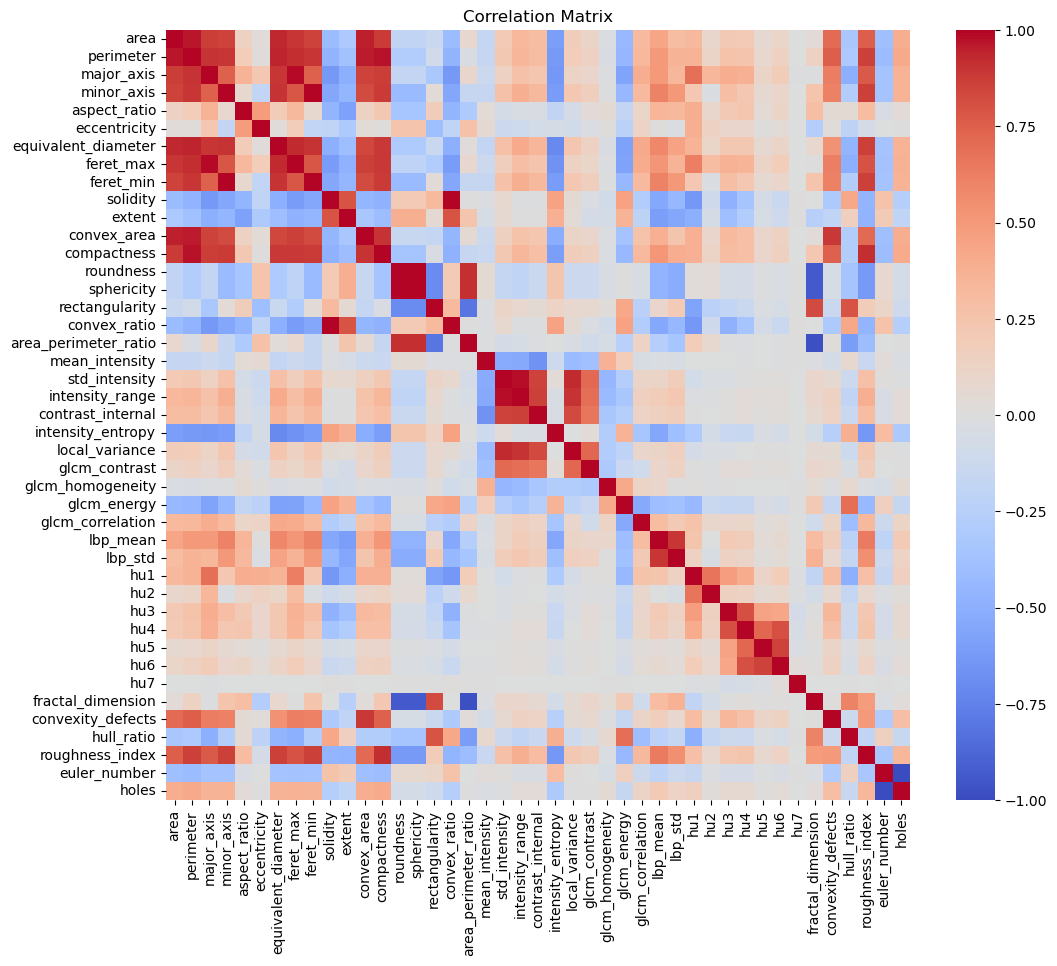

In [10]:
# Numerical Columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

#  Correlation matrix
corr_matrix = numeric_df.corr()

#  Highly correlated pairs
threshold = 0.9
high_corr = (corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1.0)  
print("Variables highly correlated (> 0.9):")
for col in high_corr.columns:
    correlated_cols = high_corr.index[high_corr[col]].tolist()
    if correlated_cols:
        print(f"{col} ↔ {correlated_cols}")

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

 Correlation Matrix — Updated Dataset

After correcting the feature extractor (fixing `convexity_defects`,
`hull_ratio`, and `fractal_dimension`), the correlation matrix reveals
some new relationships that were previously hidden by numerical artefacts:

- **`roundness` ↔ `fractal_dimension`** (>0.9) — now that `fractal_dimension`
  returns `NaN` instead of 0 for invalid cases, its real distribution emerges
  and shows a strong mathematical relationship with `roundness`, as both
  depend on the perimeter/area ratio.
- **`compactness` ↔ `roughness_index`** (>0.9) — a new redundancy detected,
  as both capture contour irregularity through similar geometric formulas.
- **`area_perimeter_ratio`** now correlates strongly with `roundness`,
  `sphericity` and `fractal_dimension`, forming a block of redundant
  shape descriptors.

The core structure remains unchanged: the size block (`area`, `perimeter`,
`equivalent_diameter`, `feret_max`, `convex_area`), the intensity block
(`std_intensity`, `intensity_range`, `local_variance`) and the Hu moments
block maintain the same correlations as before.

These new redundancies do not affect the clustering variable selection,
as `fractal_dimension`, `area_perimeter_ratio` and `roughness_index`
are not part of `columnas_clustering`.

### Data reduction

In [11]:
# Columns for clustering
columns_clustering = [
    # Size
    "perimeter",
    "equivalent_diameter",

    # Form
    "roundness",        
    "aspect_ratio",
    "compactness",
    "solidity",

    # Intensity / texture
    "mean_intensity",
    "std_intensity",
    "intensity_entropy",
    "glcm_energy",
    "glcm_correlation",
    "lbp_mean",

    # Invariant moments
    "hu1",
    "hu2",
    "hu4",
    "hu7",

    # Topology / morphology
    "euler_number",
    "holes",
    "convexity_defects"
]

df_clustering = df[columns_clustering].copy()
print("Columns for clustering:")
print(df_clustering.columns)
print("\nFirst rows of the dataset:")
print(df_clustering.head())

Columns for clustering:
Index(['perimeter', 'equivalent_diameter', 'roundness', 'aspect_ratio',
       'compactness', 'solidity', 'mean_intensity', 'std_intensity',
       'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean',
       'hu1', 'hu2', 'hu4', 'hu7', 'euler_number', 'holes',
       'convexity_defects'],
      dtype='object')

First rows of the dataset:
   perimeter  equivalent_diameter  roundness  aspect_ratio  compactness  \
0  15.656854             5.411516   1.179040      1.421224    10.658134   
1  17.485281             5.753627   1.068656      1.157349    11.759041   
2  16.485281             4.787307   0.832319      1.172905    15.098028   
3  13.828427             4.787307   1.182869      1.388450    10.623633   
4  17.656854             6.076508   1.168910      1.416381    10.750500   

   solidity  mean_intensity  std_intensity  intensity_entropy  glcm_energy  \
0  0.920000      199.956522       2.926316           3.211332     0.166667   
1  0.896552   

### Null values

In [12]:
print("\n Null values by column:")
print(df_clustering.isna().sum())


 Null values by column:
perimeter              0
equivalent_diameter    0
roundness              0
aspect_ratio           0
compactness            0
solidity               0
mean_intensity         0
std_intensity          0
intensity_entropy      0
glcm_energy            0
glcm_correlation       0
lbp_mean               0
hu1                    0
hu2                    0
hu4                    0
hu7                    0
euler_number           0
holes                  0
convexity_defects      0
dtype: int64


### Noisy data 




🔹 perimeter
count    197536.000000
mean          7.707780
std           9.440658
min           0.000000
1%            1.000000
50%           5.207107
99%          45.591883
max         209.775649
Name: perimeter, dtype: float64


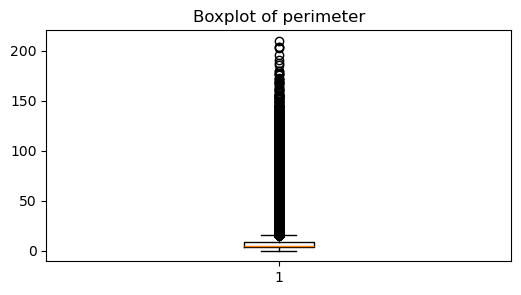


🔹 equivalent_diameter
count    197536.000000
mean          3.094801
std           1.548675
min           1.954410
1%            1.954410
50%           2.523133
99%           9.304853
max          19.478845
Name: equivalent_diameter, dtype: float64


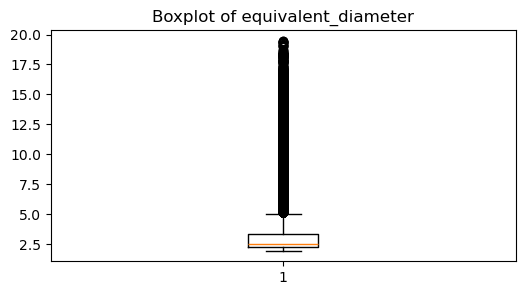


🔹 roundness
count    197536.000000
mean          5.147296
std           9.035532
min           0.000000
1%            0.363637
50%           2.353627
99%          37.699112
max          86.241934
Name: roundness, dtype: float64


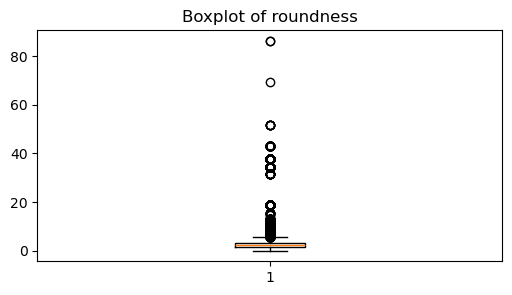


🔹 aspect_ratio
count    197536.000000
mean          1.850891
std           0.692317
min           1.000000
1%            1.000000
50%           1.732051
99%           3.793825
max           4.000000
Name: aspect_ratio, dtype: float64


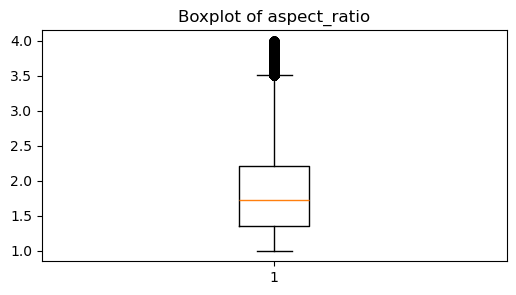


🔹 compactness
count    197536.000000
mean          6.664361
std           6.755407
min           0.000000
1%            0.333333
50%           5.339150
99%          33.293771
max         167.961157
Name: compactness, dtype: float64


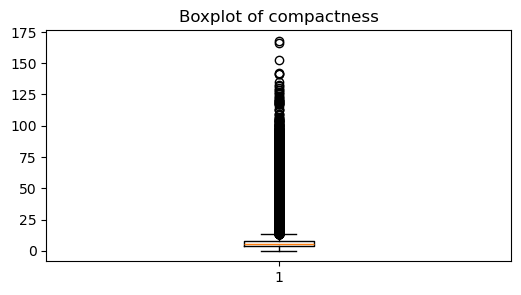


🔹 solidity
count    197536.000000
mean          0.890580
std           0.140195
min           0.300000
1%            0.477273
50%           1.000000
99%           1.000000
max           1.000000
Name: solidity, dtype: float64


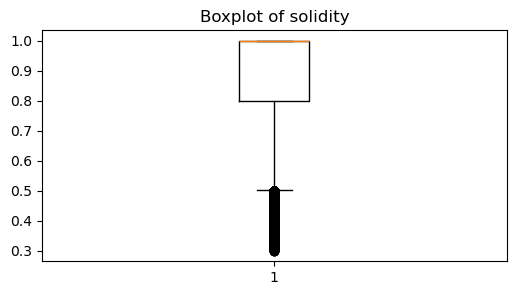


🔹 mean_intensity
count    197536.000000
mean        134.752721
std          32.214816
min           0.000000
1%           33.750000
50%         138.500000
99%         198.400000
max         241.333333
Name: mean_intensity, dtype: float64


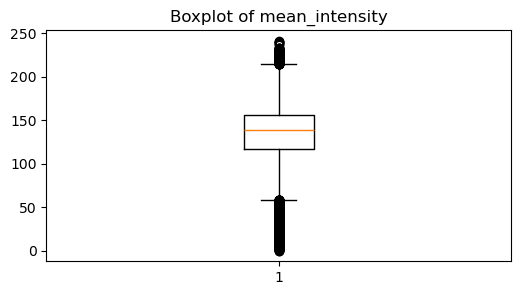


🔹 std_intensity
count    197536.000000
mean          6.886196
std           7.799826
min           0.000000
1%            0.000000
50%           3.771236
99%          35.436904
max          62.308988
Name: std_intensity, dtype: float64


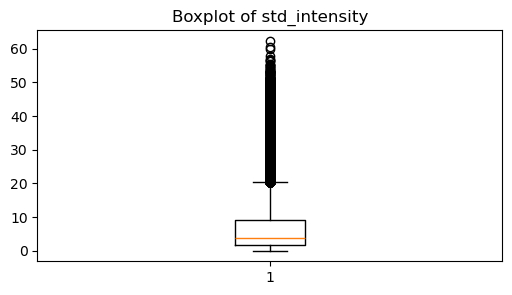


🔹 intensity_entropy
count    197536.000000
mean          3.387344
std           0.072027
min           2.023023
1%            3.084542
50%           3.409439
99%           3.436523
max           3.436523
Name: intensity_entropy, dtype: float64


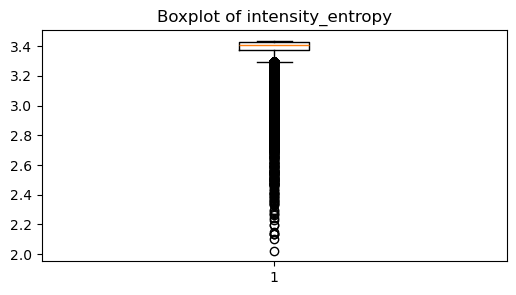


🔹 glcm_energy
count    197536.000000
mean          0.330298
std           0.165798
min           0.000000
1%            0.000000
50%           0.322749
99%           0.707107
max           1.000000
Name: glcm_energy, dtype: float64


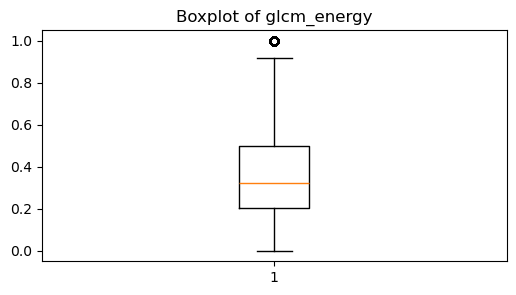


🔹 glcm_correlation
count    197536.000000
mean          0.156868
std           0.553887
min          -1.000000
1%           -1.000000
50%           0.241026
99%           1.000000
max           1.000000
Name: glcm_correlation, dtype: float64


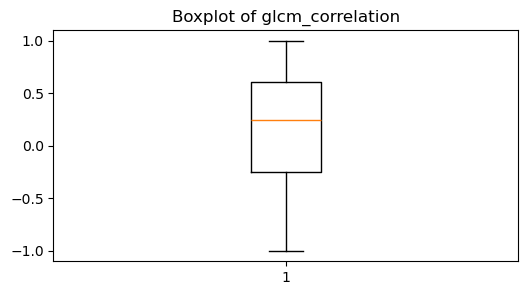


🔹 lbp_mean
count    197536.000000
mean         64.628978
std          30.916145
min           0.666667
1%            4.500000
50%          67.500000
99%         127.082073
max         255.000000
Name: lbp_mean, dtype: float64


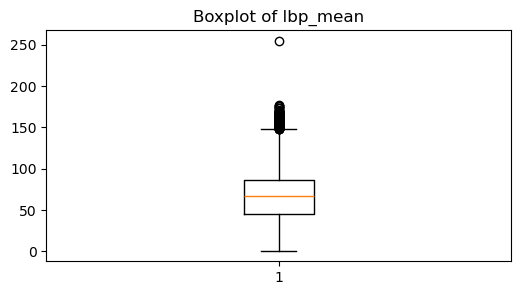


🔹 hu1
count    197536.000000
mean          0.224881
std           0.109230
min           0.125000
1%            0.125000
50%           0.190825
99%           0.594953
max           4.081633
Name: hu1, dtype: float64


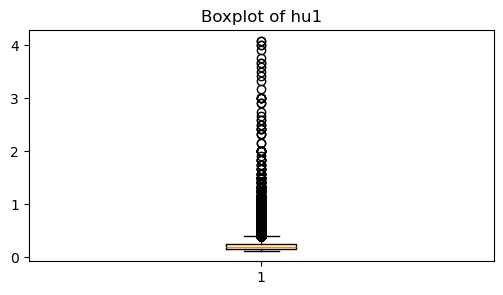


🔹 hu2
count    197536.000000
mean          0.033294
std           0.155533
min           0.000000
1%            0.000000
50%           0.009338
99%           0.237301
max          16.659725
Name: hu2, dtype: float64


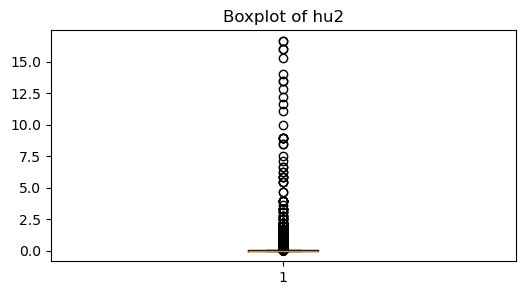


🔹 hu4
count    197536.000000
mean          0.000877
std           0.004668
min           0.000000
1%            0.000000
50%           0.000102
99%           0.012763
max           0.461733
Name: hu4, dtype: float64


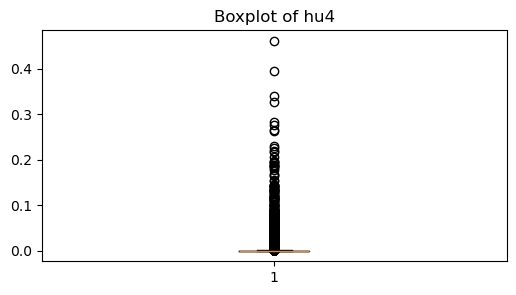


🔹 hu7
count    197536.000000
mean         -0.000001
std           0.000548
min          -0.114030
1%           -0.000039
50%           0.000000
99%           0.000037
max           0.106310
Name: hu7, dtype: float64


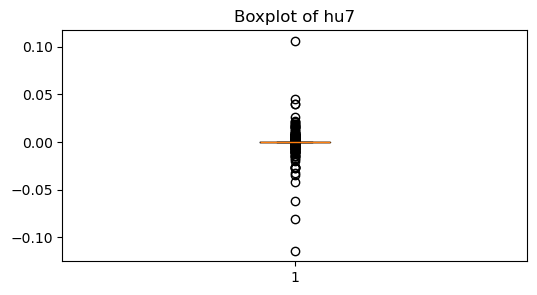


🔹 euler_number
count    197536.000000
mean          0.956621
std           0.263058
min          -9.000000
1%            0.000000
50%           1.000000
99%           1.000000
max           1.000000
Name: euler_number, dtype: float64


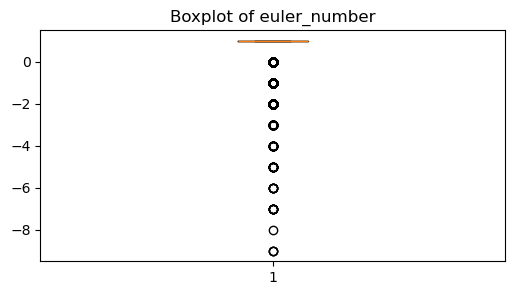


🔹 holes
count    197536.000000
mean          0.043379
std           0.263058
min           0.000000
1%            0.000000
50%           0.000000
99%           1.000000
max          10.000000
Name: holes, dtype: float64


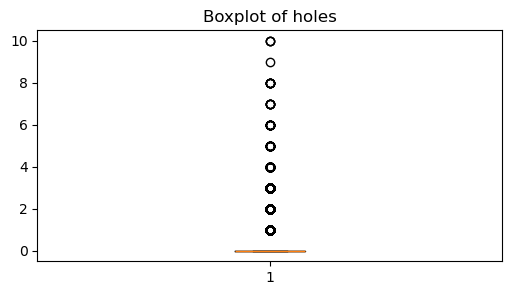


🔹 convexity_defects
count    197536.000000
mean          1.175897
std          11.711799
min           0.000000
1%            0.000000
50%           0.000000
99%          30.500000
max         546.000000
Name: convexity_defects, dtype: float64


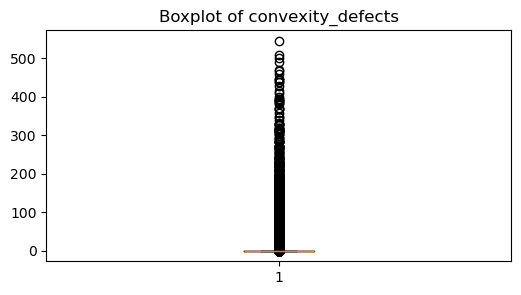

In [13]:
for col in df_clustering.columns:
    print(f"\n🔹 {col}")
    print(df_clustering[col].describe(percentiles=[0.01, 0.99]))
    
    plt.figure(figsize=(6,3))
    plt.boxplot(df_clustering[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



After removing degenerate particles (`min_area=3`, `perimeter=0` filter),
the boxplots show notable improvements in several variables that were
previously collapsed due to the dominance of 1px² particles with constant metrics.

**Variables that improved significantly**

- **`solidity`** — previously collapsed at 1.0 with no visible box, now shows
  a well-defined distribution between 0.8-1.0 with a real range down to 0.3,
  reflecting the actual shape variability of real particles.

- **`aspect_ratio`** — previously collapsed near 1.0, now shows a clear box
  between 1.5-2.0, indicating that real particles are predominantly elongated
  rather than perfectly circular.

- **`std_intensity`** — previously collapsed near 0, now shows a visible box
  with median ~5 and range up to 20, capturing the real internal intensity
  variation of particles.

- **`glcm_energy`** — previously collapsed, now shows a wide box between
  0.25-0.45, reflecting meaningful texture homogeneity differences between
  particles.

- **`glcm_correlation`** — previously collapsed with extreme outliers, now
  shows a well-spread box between -0.5 and 0.75, capturing real spatial
  correlation patterns in particle texture.

- **`lbp_mean`** — previously near 0, now centred between 50-75 with a
  clear interquartile range, reflecting real local texture patterns.

**Variables that remain similar**

- **`perimeter`, `compactness`, `roundness`, `hu1`, `hu2`** — still show
  a collapsed box with a long upper tail. This is expected and reflects the
  natural distribution of predominantly small particles with a few larger ones.

- **`convexity_defects`** — still shows negative values and a long tail,
  which will be addressed in the outlier treatment step.

- **`euler_number`, `holes`** — remain highly concentrated at 0/1 with
  very few outliers, consistent with most particles having simple topology.

**Conclusion**

The six variables that improved were artificially collapsed in the original
dataset by the 901,970 degenerate 1px² particles, which had constant metrics
across all observations. The cleaned dataset now reflects the true variability
of real particles, making these variables genuinely informative for clustering.

### Outliers treatment

In [14]:
df_clean = df_clustering.copy()

# ── 1. PHYSICAL LIMITS ────────────────────────────────────────────
# roundness: discretization artefacts can give >1, use p99 instead of hard clip
p99_round = df_clean['roundness'].quantile(0.99)
df_clean['roundness'] = df_clean['roundness'].clip(upper=p99_round)

# solidity: bounded [0, 1] by definition
df_clean['solidity'] = df_clean['solidity'].clip(0.0, 1.0)

# glcm_correlation: bounded [-1, 1] by definition
df_clean['glcm_correlation'] = df_clean['glcm_correlation'].clip(-1.0, 1.0)

# glcm_energy: bounded [0, 1] by definition
df_clean['glcm_energy'] = df_clean['glcm_energy'].clip(0.0, 1.0)

# convexity_defects: must be >= 0
df_clean['convexity_defects'] = df_clean['convexity_defects'].clip(lower=0.0)

# aspect_ratio: bounded [1, 4] by extractor config
df_clean['aspect_ratio'] = df_clean['aspect_ratio'].clip(1.0, 4.0)

# ── 2. SKEWED → log1p + winsorize p99 ─────────────────────────────
# equivalent_diameter and lbp_mean removed — not skewed / not log-scale
skewed_vars = ['perimeter', 'compactness', 'hu1', 'hu2', 'hu4', 'convexity_defects']

for var in skewed_vars:
    p99 = df_clean[var].quantile(0.99)
    df_clean[var] = df_clean[var].clip(upper=p99)
    df_clean[var] = np.log1p(df_clean[var])

# ── 3. WINSORIZE ONLY (no log) ─────────────────────────────────────
# equivalent_diameter: near-normal, just winsorize
p99_diam = df_clean['equivalent_diameter'].quantile(0.99)
df_clean['equivalent_diameter'] = df_clean['equivalent_diameter'].clip(upper=p99_diam)

# lbp_mean: [0-255] range, no log
p99_lbp = df_clean['lbp_mean'].quantile(0.99)
df_clean['lbp_mean'] = df_clean['lbp_mean'].clip(upper=p99_lbp)

# std_intensity: long upper tail
p99_std = df_clean['std_intensity'].quantile(0.99)
df_clean['std_intensity'] = df_clean['std_intensity'].clip(upper=p99_std)

# hu7: symmetric, both tails
p1_hu7  = df_clean['hu7'].quantile(0.01)
p99_hu7 = df_clean['hu7'].quantile(0.99)
df_clean['hu7'] = df_clean['hu7'].clip(p1_hu7, p99_hu7)

# ── 4. DISCRETE / TOPOLOGICAL ─────────────────────────────────────
df_clean['euler_number'] = df_clean['euler_number'].clip(-10, 1)
df_clean['holes']        = df_clean['holes'].clip(0, 10)

# ── 5. VERIFY ─────────────────────────────────────────────────────
print(f"{'Variable':<25} {'Min':>8} {'Median':>8} {'Max':>8} {'NaN':>6}")
print("-" * 60)
for col in df_clean.columns:
    print(f"{col:<25} {df_clean[col].min():>8.3f} "
          f"{df_clean[col].median():>8.3f} "
          f"{df_clean[col].max():>8.3f} "
          f"{df_clean[col].isna().sum():>6}")

Variable                       Min   Median      Max    NaN
------------------------------------------------------------
perimeter                    0.000    1.826    3.841      0
equivalent_diameter          1.954    2.523    9.305      0
roundness                    0.000    2.354   37.699      0
aspect_ratio                 1.000    1.732    4.000      0
compactness                  0.000    1.847    3.535      0
solidity                     0.300    1.000    1.000      0
mean_intensity               0.000  138.500  241.333      0
std_intensity                0.000    3.771   35.437      0
intensity_entropy            2.023    3.409    3.437      0
glcm_energy                  0.000    0.323    1.000      0
glcm_correlation            -1.000    0.241    1.000      0
lbp_mean                     0.667   67.500  127.082      0
hu1                          0.118    0.175    0.467      0
hu2                          0.000    0.009    0.213      0
hu4                          0.000    0

In [15]:
print(f"roundness > 1: {(df_clean['roundness'] > 1).sum()} ({(df_clean['roundness'] > 1).mean()*100:.1f}%)")
print(df_clean['roundness'].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

roundness > 1: 180143 (91.2%)
count    197536.000000
mean          5.144682
std           9.023716
min           0.000000
25%           1.600213
50%           2.353627
75%           3.234073
90%           8.624193
95%          37.699112
99%          37.699112
max          37.699112
Name: roundness, dtype: float64


In [16]:
print(df_clean['hu7'].describe())
print(f"Min: {df_clean['hu7'].min():.2e}")
print(f"Max: {df_clean['hu7'].max():.2e}")

count    1.975360e+05
mean    -7.471760e-09
std      6.367045e-06
min     -3.875993e-05
25%     -6.617445e-24
50%      0.000000e+00
75%      6.617445e-24
max      3.716446e-05
Name: hu7, dtype: float64
Min: -3.88e-05
Max: 3.72e-05


In [17]:
# Columns for clustering
columns_clustering = [
    # Size
    "perimeter",
    "equivalent_diameter",

    # Form        
    "aspect_ratio",
    "compactness",
    "solidity",

    # Intensity / texture
    "mean_intensity",
    "std_intensity",
    "intensity_entropy",
    "glcm_energy",
    "glcm_correlation",
    "lbp_mean",

    # Invariant moments
    "hu1",
    "hu2",
    "hu4",

    # Topology / morphology
    "euler_number",
    "holes",
    "convexity_defects"
]

df_clustering = df[columns_clustering].copy()
print(f"Final clustering variables: {len(columns_clustering)}")
print(df_clustering.columns.tolist())

Final clustering variables: 17
['perimeter', 'equivalent_diameter', 'aspect_ratio', 'compactness', 'solidity', 'mean_intensity', 'std_intensity', 'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'hu1', 'hu2', 'hu4', 'euler_number', 'holes', 'convexity_defects']


**Outlier Treatment Summary**

 Variable removal

Two variables were removed from the clustering feature set after outlier analysis:

- **`roundness`**: despite being mathematically bounded to [0, 1] under ideal
  conditions (`4πA/P²`), pixel-grid discretization causes 91.2% of values to
  exceed 1, making the distribution unreliable. Since `compactness` (`P²/A`)
  captures the same geometric information as its mathematical inverse, `roundness`
  is redundant and was removed.

- **`hu7`**: values fall in the 1e-5 scale, numerically unstable for the small
  particles in this dataset (mostly 3-10px²). The signal-to-noise ratio is too
  low to be meaningful for clustering.

 Outlier treatment applied to remaining variables

The treatment strategy was determined per variable based on physical limits,
distribution shape, and domain knowledge:

- **Physical limits** (`solidity`, `glcm_energy`, `glcm_correlation`,
  `aspect_ratio`, `convexity_defects`) → clipped to their valid mathematical
  or extractor-defined range.

- **Skewed distributions** (`perimeter`, `compactness`, `hu1`, `hu2`, `hu4`,
  `convexity_defects`) → winsorized at p99, then `log1p` transformation to
  reduce the effect of the long upper tail.

- **Winsorize only** (`equivalent_diameter`, `lbp_mean`, `std_intensity`,
  `hu7`) → clipped at p99 without log transformation, as their distributions
  are near-normal or on a linear scale where log would have no physical meaning.

- **Discrete / topological** (`euler_number`, `holes`) → clipped to a
  physically meaningful range ([-10, 1] and [0, 10] respectively), as extreme
  values correspond to highly complex particle shapes rarely seen in practice.

- **No treatment** (`mean_intensity`, `intensity_entropy`, `glcm_energy`,
  `glcm_correlation`) → distributions already within valid physical bounds
  with no extreme outliers requiring correction.

All variables will subsequently be scaled with `RobustScaler`, which is
robust to any moderate residual outliers that may remain after the
transformations above.

# 2. Feature Scaling

In [18]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np

# Apply outlier treatment first (if not already done)
df_clean = df_clustering.copy()

# ── 1. PHYSICAL LIMITS ────────────────────────────────────────────
df_clean['solidity']           = df_clean['solidity'].clip(0.0, 1.0)
df_clean['glcm_correlation']   = df_clean['glcm_correlation'].clip(-1.0, 1.0)
df_clean['glcm_energy']        = df_clean['glcm_energy'].clip(0.0, 1.0)
df_clean['convexity_defects']  = df_clean['convexity_defects'].clip(lower=0.0)
df_clean['aspect_ratio']       = df_clean['aspect_ratio'].clip(1.0, 4.0)

# ── 2. SKEWED → clip p99 + log1p ──────────────────────────────────
skewed_vars = ['perimeter', 'compactness', 'hu1', 'hu2', 'hu4', 'convexity_defects']
for var in skewed_vars:
    p99 = df_clean[var].quantile(0.99)
    df_clean[var] = df_clean[var].clip(upper=p99)
    df_clean[var] = np.log1p(df_clean[var])

# ── 3. WINSORIZE ONLY ─────────────────────────────────────────────
for var in ['equivalent_diameter', 'lbp_mean', 'std_intensity']:
    p99 = df_clean[var].quantile(0.99)
    df_clean[var] = df_clean[var].clip(upper=p99)

# ── 4. DISCRETE ───────────────────────────────────────────────────
df_clean['euler_number'] = df_clean['euler_number'].clip(-10, 1)
df_clean['holes']        = df_clean['holes'].clip(0, 10)

# ── 5. ROBUST SCALING ─────────────────────────────────────────────
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns, index=df_clean.index)

# ── 6. VERIFY ─────────────────────────────────────────────────────
print("=== After RobustScaler ===")
print(f"{'Variable':<25} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col in X_scaled.columns:
    q1  = X_scaled[col].quantile(0.25)
    q3  = X_scaled[col].quantile(0.75)
    iqr = q3 - q1
    print(f"{col:<25} {X_scaled[col].median():>8.3f} "
          f"{iqr:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN values: {X_scaled.isna().sum().sum()}")

=== After RobustScaler ===
Variable                    Median      IQR      Min      Max
-------------------------------------------------------
perimeter                    0.000    1.000   -2.399    2.648
equivalent_diameter          0.000    1.000   -0.504    6.010
aspect_ratio                 0.000    1.000   -0.849    2.630
compactness                  0.000    1.000   -3.107    2.840
solidity                     0.000    1.000   -3.500    0.000
mean_intensity               0.000    1.000   -3.534    2.624
std_intensity                0.000    1.000   -0.501    4.207
intensity_entropy            0.000    1.000  -25.261    0.493
glcm_energy                  0.000    1.000   -1.091    2.289
glcm_correlation             0.000    1.000   -1.445    0.883
lbp_mean                     0.000    1.000   -1.617    1.442
hu1                          0.000    1.000   -0.687    3.531
hu2                          0.000    1.000   -0.284    6.211
hu4                          0.000    1.000   -0.

In [19]:
# Verificar distribución de las tres problemáticas
for col in ['intensity_entropy', 'euler_number', 'holes', 'convexity_defects']:
    print(f"\n{col}:")
    print(df_clean[col].describe(percentiles=[.01, .25, .50, .75, .99]))


intensity_entropy:
count    197536.000000
mean          3.387344
std           0.072027
min           2.023023
1%            3.084542
25%           3.374603
50%           3.409439
75%           3.429486
99%           3.436523
max           3.436523
Name: intensity_entropy, dtype: float64

euler_number:
count    197536.000000
mean          0.956621
std           0.263058
min          -9.000000
1%            0.000000
25%           1.000000
50%           1.000000
75%           1.000000
99%           1.000000
max           1.000000
Name: euler_number, dtype: float64

holes:
count    197536.000000
mean          0.043379
std           0.263058
min           0.000000
1%            0.000000
25%           0.000000
50%           0.000000
75%           0.000000
99%           1.000000
max          10.000000
Name: holes, dtype: float64

convexity_defects:
count    197536.000000
mean          0.096762
std           0.492631
min           0.000000
1%            0.000000
25%           0.000000
50%   

In [20]:
# Fix intensity_entropy — winsorize both tails
p1_ent  = df_clean['intensity_entropy'].quantile(0.01)
p99_ent = df_clean['intensity_entropy'].quantile(0.99)
df_clean['intensity_entropy'] = df_clean['intensity_entropy'].clip(p1_ent, p99_ent)

# Remove low-variance variables — IQR=0, useless for clustering
columns_clustering = [col for col in columns_clustering 
                       if col not in ['euler_number', 'holes', 'convexity_defects']]

df_clean = df_clean[columns_clustering].copy()
print(f"Final variables after removing zero-IQR: {len(columns_clustering)}")
print(columns_clustering)

# Re-scale
scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)

# Verify
print(f"\n{'Variable':<25} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col in X_scaled.columns:
    q1  = X_scaled[col].quantile(0.25)
    q3  = X_scaled[col].quantile(0.75)
    print(f"{col:<25} {X_scaled[col].median():>8.3f} "
          f"{q3-q1:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN: {X_scaled.isna().sum().sum()}")

Final variables after removing zero-IQR: 14
['perimeter', 'equivalent_diameter', 'aspect_ratio', 'compactness', 'solidity', 'mean_intensity', 'std_intensity', 'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'hu1', 'hu2', 'hu4']

Variable                    Median      IQR      Min      Max
-------------------------------------------------------
perimeter                    0.000    1.000   -2.399    2.648
equivalent_diameter          0.000    1.000   -0.504    6.010
aspect_ratio                 0.000    1.000   -0.849    2.630
compactness                  0.000    1.000   -3.107    2.840
solidity                     0.000    1.000   -3.500    0.000
mean_intensity               0.000    1.000   -3.534    2.624
std_intensity                0.000    1.000   -0.501    4.207
intensity_entropy            0.000    1.000   -5.920    0.493
glcm_energy                  0.000    1.000   -1.091    2.289
glcm_correlation             0.000    1.000   -1.445    0.883
lbp_mean     

In [21]:
# Check the problematic ones
print("intensity_entropy — valores por debajo del p1:")
p1 = df_clean['intensity_entropy'].quantile(0.01)
print(f"  p1={p1:.4f}, valores < p1: {(df_clean['intensity_entropy'] < p1).sum()}")
print(df_clean['intensity_entropy'].describe(percentiles=[.01,.02,.05]))

print("\nhu4 — cola superior:")
print(df_clean['hu4'].describe(percentiles=[.95,.99,.999]))
print(f"  valores > p99: {(df_clean['hu4'] > df_clean['hu4'].quantile(0.99)).sum()}")

intensity_entropy — valores por debajo del p1:
  p1=3.0846, valores < p1: 1976
count    197536.000000
mean          3.388747
std           0.062478
min           3.084542
1%            3.084553
2%            3.167329
5%            3.260875
50%           3.409439
max           3.436523
Name: intensity_entropy, dtype: float64

hu4 — cola superior:
count    197536.000000
mean          0.000695
std           0.001840
min           0.000000
50%           0.000102
95%           0.003549
99%           0.012682
99.9%         0.012683
max           0.012683
Name: hu4, dtype: float64
  valores > p99: 1976


In [22]:
mask_ent = df_clean['intensity_entropy'] < df_clean['intensity_entropy'].quantile(0.01)
mask_hu4 = df_clean['hu4'] > df_clean['hu4'].quantile(0.99)

print(f"Filas con intensity_entropy bajo: {mask_ent.sum()}")
print(f"Filas con hu4 alto:               {mask_hu4.sum()}")
print(f"Filas que son ambas:              {(mask_ent & mask_hu4).sum()}")

Filas con intensity_entropy bajo: 1976
Filas con hu4 alto:               1976
Filas que son ambas:              85


In [23]:
# intensity_entropy: clip at p2 (p1 wasn't aggressive enough)
p2_ent = df_clean['intensity_entropy'].quantile(0.02)
df_clean['intensity_entropy'] = df_clean['intensity_entropy'].clip(lower=p2_ent)

# hu4: clip at p99.9 (the real maximum, no extreme outliers beyond)
p999_hu4 = df_clean['hu4'].quantile(0.999)
df_clean['hu4'] = df_clean['hu4'].clip(upper=p999_hu4)

# Re-scale
scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)

# Verify
print(f"{'Variable':<25} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col in X_scaled.columns:
    q1 = X_scaled[col].quantile(0.25)
    q3 = X_scaled[col].quantile(0.75)
    print(f"{col:<25} {X_scaled[col].median():>8.3f} "
          f"{q3-q1:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN: {X_scaled.isna().sum().sum()}")

Variable                    Median      IQR      Min      Max
-------------------------------------------------------
perimeter                    0.000    1.000   -2.399    2.648
equivalent_diameter          0.000    1.000   -0.504    6.010
aspect_ratio                 0.000    1.000   -0.849    2.630
compactness                  0.000    1.000   -3.107    2.840
solidity                     0.000    1.000   -3.500    0.000
mean_intensity               0.000    1.000   -3.534    2.624
std_intensity                0.000    1.000   -0.501    4.207
intensity_entropy            0.000    1.000   -4.411    0.493
glcm_energy                  0.000    1.000   -1.091    2.289
glcm_correlation             0.000    1.000   -1.445    0.883
lbp_mean                     0.000    1.000   -1.617    1.442
hu1                          0.000    1.000   -0.687    3.531
hu2                          0.000    1.000   -0.284    6.211
hu4                          0.000    1.000   -0.231   28.600

Shape: (19753

In [24]:
# Ver la distribución real de hu4
print(df_clean['hu4'].describe(percentiles=[.25,.50,.75,.90,.95,.99,.999]))
print(f"\nValores > 0.01:  {(df_clean['hu4'] > 0.01).sum()}")
print(f"Valores > 0.005: {(df_clean['hu4'] > 0.005).sum()}")
print(f"Valores > 0.001: {(df_clean['hu4'] > 0.001).sum()}")

count    197536.000000
mean          0.000695
std           0.001840
min           0.000000
25%           0.000003
50%           0.000102
75%           0.000442
90%           0.001784
95%           0.003549
99%           0.012682
99.9%         0.012683
max           0.012683
Name: hu4, dtype: float64

Valores > 0.01:  2815
Valores > 0.005: 6124
Valores > 0.001: 29913


In [25]:
from sklearn.preprocessing import StandardScaler

# hu4 needs StandardScaler instead of RobustScaler
# because IQR is too small relative to the tail
hu4_scaler = StandardScaler()
df_clean['hu4'] = hu4_scaler.fit_transform(df_clean[['hu4']])

# Re-scale the rest with RobustScaler
cols_robust = [c for c in df_clean.columns if c != 'hu4']
scaler = RobustScaler()
X_robust = scaler.fit_transform(df_clean[cols_robust])

# Combine
X_scaled = pd.DataFrame(X_robust, columns=cols_robust, index=df_clean.index)
X_scaled['hu4'] = df_clean['hu4'].values

# Verify
print(f"{'Variable':<25} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col in X_scaled.columns:
    q1 = X_scaled[col].quantile(0.25)
    q3 = X_scaled[col].quantile(0.75)
    print(f"{col:<25} {X_scaled[col].median():>8.3f} "
          f"{q3-q1:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN: {X_scaled.isna().sum().sum()}")

Variable                    Median      IQR      Min      Max
-------------------------------------------------------
perimeter                    0.000    1.000   -2.399    2.648
equivalent_diameter          0.000    1.000   -0.504    6.010
aspect_ratio                 0.000    1.000   -0.849    2.630
compactness                  0.000    1.000   -3.107    2.840
solidity                     0.000    1.000   -3.500    0.000
mean_intensity               0.000    1.000   -3.534    2.624
std_intensity                0.000    1.000   -0.501    4.207
intensity_entropy            0.000    1.000   -4.411    0.493
glcm_energy                  0.000    1.000   -1.091    2.289
glcm_correlation             0.000    1.000   -1.445    0.883
lbp_mean                     0.000    1.000   -1.617    1.442
hu1                          0.000    1.000   -0.687    3.531
hu2                          0.000    1.000   -0.284    6.211
hu4                         -0.322    0.239   -0.378    6.515

Shape: (19753

# 3. Clustering

## 3.1 Initial exploration

Two preliminary analyses are run before the full comparison:
- **HDBSCAN on the full dataset** — density-based, no k required, gives a
  first estimate of the natural number of clusters
- **Elbow + Silhouette for KMeans** — guides the choice of k for
  partition-based methods

In [ ]:
# ── HDBSCAN on full dataset ────────────────────────────────────────
print("Running HDBSCAN on full dataset...")
hdb_full = HDBSCAN(min_cluster_size=50, min_samples=10,
                   cluster_selection_method='eom')
labels_hdb_full = hdb_full.fit_predict(X_scaled)

n_hdb  = len(set(labels_hdb_full)) - (1 if -1 in labels_hdb_full else 0)
noise  = (labels_hdb_full == -1).sum()
mask   = labels_hdb_full != -1

print(f"  Clusters found: {n_hdb}")
print(f"  Noise points:   {noise} ({noise/len(labels_hdb_full)*100:.1f}%)")
if n_hdb > 1:
    sil = silhouette_score(X_scaled[mask], labels_hdb_full[mask],
                           sample_size=10000, random_state=42)
    print(f"  Silhouette:     {sil:.4f}")

Running HDBSCAN on full dataset...


In [ ]:
# ── Elbow + Silhouette for KMeans ─────────────────────────────────
print("Running elbow + silhouette for KMeans...")
K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels,
                                        sample_size=10000, random_state=42))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow — inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.savefig('elbow_silhouette_1000.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
The elbow curve shows no clear inflection point, and the silhouette score
peaks at k=2 and decreases monotonically — consistent with the 2,000×2,000
dataset. However, HDBSCAN finds 148 clusters with 54.1% noise and
silhouette=-0.03, indicating that the data structure at 1,000×1,000
resolution is dominated by pixel-area quantization artefacts rather than
genuine morphological groups.

## 3.2 Algorithm comparison

All major clustering families are tested with k=2, 3, 4.
Memory-intensive algorithms (Agglomerative, Spectral, HDBSCAN on sample,
UMAP+HDBSCAN) are run on a random sample of 10,000 particles.
DBSCAN and Mean Shift are subsequently re-evaluated on larger samples
to assess result stability. BIRCH was excluded — it ran for over
900 minutes without completing.

In [ ]:
# ── Sample for memory-intensive algorithms ─────────────────────────
SAMPLE_SIZE = 10000
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample   = X_scaled.iloc[idx_sample]

results         = {}
N_CLUSTERS_LIST = [2, 3, 4]

print(f"{'Algorithm':<22} {'k':>3} {'Silhouette':>12} {'DB↓':>10} {'CH↑':>12} {'Note'}")
print("-" * 75)



### 3.2.1 Partition Based

In [ ]:
# ── Partition-based — full dataset ────────────────────────────────
# KMeans
for k in N_CLUSTERS_LIST:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"KMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'KMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# MiniBatchKMeans
for k in N_CLUSTERS_LIST:
    mb = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42,
                         batch_size=10000)
    labels = mb.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"MiniBatchKMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                         'davies_bouldin': db, 'calinski': ch}
    print(f"{'MiniBatchKMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# GMM
for k in N_CLUSTERS_LIST:
    gmm = GaussianMixture(n_components=k, n_init=3, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"GMM_k{k}"] = {'labels': labels, 'silhouette': sil,
                              'davies_bouldin': db, 'calinski': ch}
    print(f"{'GMM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")



### 3.2.2 Hierarchical

In [ ]:
# ── Hierarchical — sample only ────────────────────────────────────
for k in N_CLUSTERS_LIST:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_sample = agg.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_sample)
    ch  = calinski_harabasz_score(X_sample, labels_sample)
    results[f"Agglomerative_k{k}"] = {'labels': labels_sample,
                                       'silhouette': sil,
                                       'davies_bouldin': db, 'calinski': ch}
    print(f"{'Agglomerative':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} sample n={SAMPLE_SIZE}")



### 3.2.3 Density Based

In [ ]:
# ── Density-based — sample only ───────────────────────────────────
# HDBSCAN
hdb_s = HDBSCAN(min_cluster_size=100, min_samples=10,
                cluster_selection_method='eom')
labels_hdb_s = hdb_s.fit_predict(X_sample)
mask_s   = labels_hdb_s != -1
n_hdb_s  = len(set(labels_hdb_s[mask_s]))
noise_s  = (labels_hdb_s == -1).mean() * 100
if n_hdb_s > 1:
    sil = silhouette_score(X_sample[mask_s], labels_hdb_s[mask_s],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_s], labels_hdb_s[mask_s])
    ch  = calinski_harabasz_score(X_sample[mask_s], labels_hdb_s[mask_s])
    results['HDBSCAN_sample'] = {'labels': labels_hdb_s, 'silhouette': sil,
                                  'davies_bouldin': db, 'calinski': ch}
    print(f"{'HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_hdb_s} noise={noise_s:.1f}% sample")

# DBSCAN — k-distance plot
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
dist_sorted = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='#378ADD')
plt.title('k-distance plot — DBSCAN eps selection (1000×1000)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5')
plt.legend(); plt.tight_layout()
plt.savefig('dbscan_eps_1000.png', dpi=150, bbox_inches='tight')
plt.show()

for eps in [1.0, 1.5, 2.0]:
    db_model  = DBSCAN(eps=eps, min_samples=10)
    labels_db = db_model.fit_predict(X_sample)
    n_db      = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_db  = (labels_db == -1).mean() * 100
    if n_db > 1:
        mask_db = labels_db != -1
        sil = silhouette_score(X_sample[mask_db], labels_db[mask_db],
                               random_state=42)
        db  = davies_bouldin_score(X_sample[mask_db], labels_db[mask_db])
        ch  = calinski_harabasz_score(X_sample[mask_db], labels_db[mask_db])
        results[f"DBSCAN_eps{eps}"] = {'labels': labels_db, 'silhouette': sil,
                                        'davies_bouldin': db, 'calinski': ch}
        print(f"{'DBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"eps={eps} k={n_db} noise={noise_db:.1f}% sample")
    else:
        print(f"DBSCAN eps={eps}: k={n_db} — no valid clusters")

# OPTICS — full dataset
print("\nRunning OPTICS on full dataset...")
opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.02, n_jobs=-1)
labels_opt = opt.fit_predict(X_scaled)
mask_opt   = labels_opt != -1
n_opt      = len(set(labels_opt[mask_opt]))
noise_opt  = (labels_opt == -1).mean() * 100
if n_opt > 1:
    sil = silhouette_score(X_scaled[mask_opt], labels_opt[mask_opt],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled[mask_opt], labels_opt[mask_opt])
    ch  = calinski_harabasz_score(X_scaled[mask_opt], labels_opt[mask_opt])
    results['OPTICS'] = {'labels': labels_opt, 'silhouette': sil,
                          'davies_bouldin': db, 'calinski': ch}
    print(f"{'OPTICS':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_opt} noise={noise_opt:.1f}% full dataset")
else:
    print(f"OPTICS: k={n_opt} — no valid clusters")

# Mean Shift — sample
bandwidth = estimate_bandwidth(X_sample, quantile=0.2, random_state=42)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_sample)
n_ms = len(set(labels_ms))
sil  = silhouette_score(X_sample, labels_ms, random_state=42)
db   = davies_bouldin_score(X_sample, labels_ms)
ch   = calinski_harabasz_score(X_sample, labels_ms)
results['MeanShift'] = {'labels': labels_ms, 'silhouette': sil,
                         'davies_bouldin': db, 'calinski': ch}
print(f"{'MeanShift':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
      f"k={n_ms} sample n={SAMPLE_SIZE}")



### 3.2.3 Spectral

In [ ]:
# ── Graph / Spectral — sample only ────────────────────────────────
for k in N_CLUSTERS_LIST:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                              n_neighbors=10, random_state=42, n_jobs=-1)
    labels_spec = spec.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_spec, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_spec)
    ch  = calinski_harabasz_score(X_sample, labels_spec)
    results[f"Spectral_k{k}"] = {'labels': labels_spec, 'silhouette': sil,
                                   'davies_bouldin': db, 'calinski': ch}
    print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"sample n={SAMPLE_SIZE}")



### 3.2.4 Neural

In [ ]:
# ── Neural — SOM — full dataset ────────────────────────────────────
from minisom import MiniSom
print("\nRunning SOM on full dataset...")
X_scaled_np = X_scaled.values
map_size = int(np.sqrt(5 * np.sqrt(len(X_scaled_np))))
print(f"  Map size: {map_size}×{map_size} ({map_size**2} neurons)")
som = MiniSom(map_size, map_size, X_scaled_np.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_scaled_np)
som.train(X_scaled_np, num_iteration=10000, verbose=False)
winner_coords = np.array([som.winner(x) for x in X_scaled_np])

for k in N_CLUSTERS_LIST:
    km_som = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_som = km_som.fit_predict(winner_coords)
    sil = silhouette_score(X_scaled, labels_som,
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels_som)
    ch  = calinski_harabasz_score(X_scaled, labels_som)
    results[f"SOM_k{k}"] = {'labels': labels_som, 'silhouette': sil,
                              'davies_bouldin': db, 'calinski': ch}
    print(f"{'SOM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# ── UMAP + HDBSCAN — sample ────────────────────────────────────────
print("\nRunning UMAP + HDBSCAN...")
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% sample")

## 3.3 Visualization

## 3.4 Best Results

## 3.5 Resolution Comparison

Running HDBSCAN...


c:\Users\Usuario\anaconda3\envs\nlp\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  Clusters found: 148
  Noise points:   106870 (54.1%)
  Silhouette:     -0.0061

Running elbow + silhouette for KMeans...
  k=2  inertia=1688993.8  silhouette=0.3571
  k=3  inertia=1448147.9  silhouette=0.2799
  k=4  inertia=1246725.4  silhouette=0.2890
  k=5  inertia=1110792.9  silhouette=0.2578
  k=6  inertia=978736.8  silhouette=0.2658
  k=7  inertia=904768.7  silhouette=0.2412
  k=8  inertia=843196.8  silhouette=0.2625
  k=9  inertia=795075.8  silhouette=0.2470
  k=10  inertia=752939.0  silhouette=0.2540


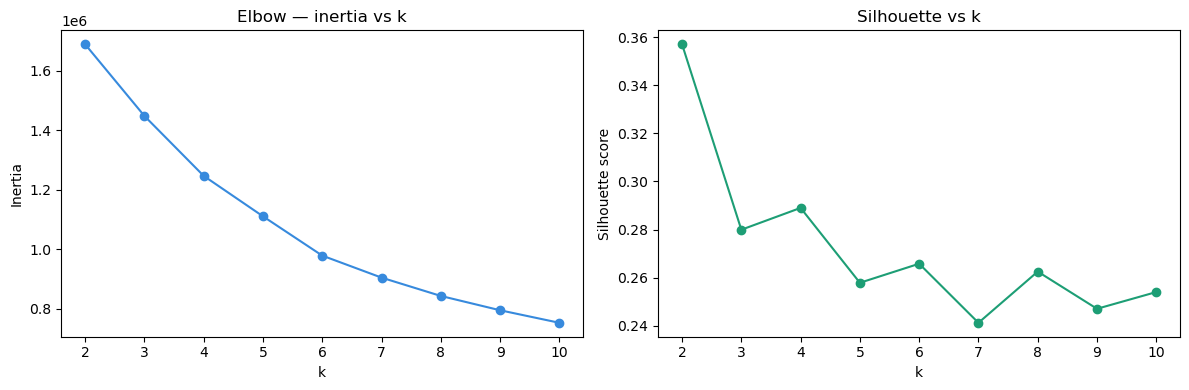

In [31]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── 1. HDBSCAN — no k needed, best starting point ─────────────────
print("Running HDBSCAN...")
hdb = HDBSCAN(min_cluster_size=50, min_samples=10, cluster_selection_method='eom')
labels_hdb = hdb.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise_hdb    = (labels_hdb == -1).sum()
print(f"  Clusters found: {n_clusters_hdb}")
print(f"  Noise points:   {n_noise_hdb} ({n_noise_hdb/len(labels_hdb)*100:.1f}%)")

# Silhouette only on non-noise points
mask = labels_hdb != -1
if len(set(labels_hdb[mask])) > 1:
    sil_hdb = silhouette_score(X_scaled[mask], labels_hdb[mask], sample_size=10000)
    print(f"  Silhouette:     {sil_hdb:.4f}")

# ── 2. ELBOW + SILHOUETTE — find best k for KMeans ────────────────
print("\nRunning elbow + silhouette for KMeans...")
K_RANGE   = range(2, 11)
inertias  = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow — inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Ver qué separa k=2
km2 = KMeans(n_clusters=2, init='k-means++', n_init=15, random_state=42)
labels2 = km2.fit_predict(X_scaled)

print("=== Perfil de los 2 clusters (valores originales, no escalados) ===")
df_clean['cluster'] = labels2
print(f"\nTamaño clusters:")
print(df_clean['cluster'].value_counts())

print(f"\nMedianas por cluster:")
print(df_clean.groupby('cluster').median().round(3).T)

=== Perfil de los 2 clusters (valores originales, no escalados) ===

Tamaño clusters:
cluster
0    149043
1     48493
Name: count, dtype: int64

Medianas por cluster:
cluster                    0        1
perimeter              1.650    2.654
equivalent_diameter    2.257    4.514
aspect_ratio           1.732    2.096
compactness            1.609    2.483
solidity               1.000    0.765
mean_intensity       138.500  138.458
std_intensity          3.499    4.764
intensity_entropy      3.422    3.339
glcm_energy            0.395    0.164
glcm_correlation       0.032    0.616
lbp_mean              57.900   96.055
hu1                    0.159    0.243
hu2                    0.006    0.030
hu4                   -0.322   -0.166


In [33]:
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Subsample for memory-intensive algorithms
SAMPLE_SIZE = 10000
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled.iloc[idx_sample]

results = {}
N_CLUSTERS_LIST = [2, 3, 4]

print(f"{'Algorithm':<22} {'k':>3} {'Silhouette':>12} {'DB↓':>10} {'CH↑':>12} {'Note'}")
print("-" * 75)

# ── KMeans — scales well, use full dataset ────────────────────────
for k in N_CLUSTERS_LIST:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"KMeans_k{k}"] = {'labels': labels, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'KMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# ── GMM — scales reasonably, use full dataset ─────────────────────
for k in N_CLUSTERS_LIST:
    gmm = GaussianMixture(n_components=k, n_init=3, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"GMM_k{k}"] = {'labels': labels, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'GMM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# ── Agglomerative — memory intensive, use sample ──────────────────
for k in N_CLUSTERS_LIST:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_sample = agg.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_sample)
    ch  = calinski_harabasz_score(X_sample, labels_sample)
    results[f"Agglomerative_k{k}"] = {'labels': labels_sample, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'Agglomerative':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} sample n={SAMPLE_SIZE}")

# ── HDBSCAN — use sample to avoid 148 micro-clusters ─────────────
hdb = HDBSCAN(min_cluster_size=100, min_samples=10, cluster_selection_method='eom')
labels_hdb = hdb.fit_predict(X_sample)
mask = labels_hdb != -1
n_clusters_hdb = len(set(labels_hdb[mask]))
noise_pct = (labels_hdb == -1).mean() * 100
if n_clusters_hdb > 1:
    sil = silhouette_score(X_sample[mask], labels_hdb[mask], random_state=42)
    db  = davies_bouldin_score(X_sample[mask], labels_hdb[mask])
    ch  = calinski_harabasz_score(X_sample[mask], labels_hdb[mask])
    results['HDBSCAN'] = {'labels': labels_hdb, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} k={n_clusters_hdb} noise={noise_pct:.1f}%")

Algorithm                k   Silhouette        DB↓          CH↑ Note
---------------------------------------------------------------------------
KMeans                   2       0.3603     1.4101      76592.5 full dataset
KMeans                   3       0.2806     1.4382      61091.3 full dataset
KMeans                   4       0.2882     1.3642      57945.2 full dataset
GMM                      2       0.2218     1.7340      52546.1 full dataset
GMM                      3       0.1307     1.9682      38662.5 full dataset
GMM                      4       0.1607     1.6822      40359.8 full dataset
Agglomerative            2       0.4314     1.3449       3081.9 sample n=10000
Agglomerative            3       0.3072     1.3079       2494.8 sample n=10000
Agglomerative            4       0.2060     1.6635       2322.4 sample n=10000


c:\Users\Usuario\anaconda3\envs\nlp\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN                auto       0.2178     0.9997        518.9 k=4 noise=6.5%


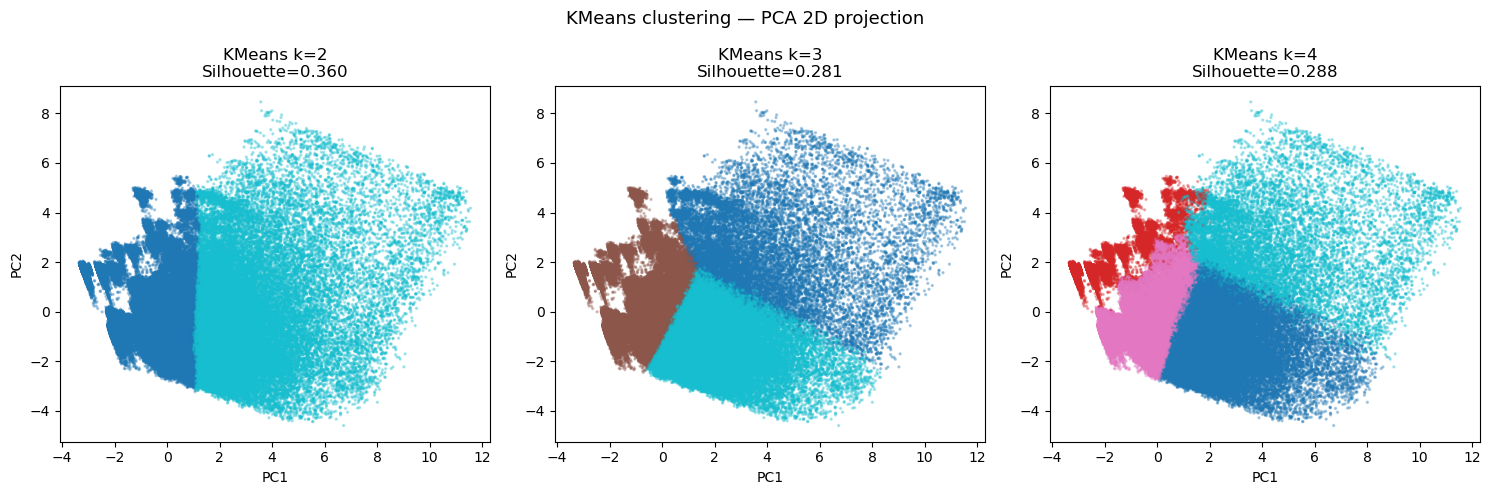

PC1 variance explained: 43.0%
PC2 variance explained: 21.3%
Total: 64.2%


In [34]:
# Visualización PCA 2D del mejor resultado — KMeans k=2
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

km2 = KMeans(n_clusters=2, init='k-means++', n_init=15, random_state=42)
labels2 = km2.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# KMeans k=2
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels2, cmap='tab10', s=2, alpha=0.3)
axes[0].set_title(f'KMeans k=2\nSilhouette=0.360')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# KMeans k=3
km3 = KMeans(n_clusters=3, init='k-means++', n_init=15, random_state=42)
labels3 = km3.fit_predict(X_scaled)
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels3, cmap='tab10', s=2, alpha=0.3)
axes[1].set_title(f'KMeans k=3\nSilhouette=0.281')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# KMeans k=4
km4 = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=42)
labels4 = km4.fit_predict(X_scaled)
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=labels4, cmap='tab10', s=2, alpha=0.3)
axes[2].set_title(f'KMeans k=4\nSilhouette=0.288')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('KMeans clustering — PCA 2D projection', fontsize=13)
plt.tight_layout()
plt.savefig('clustering_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Variance explained by PCA
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [ ]:
from sklearn.cluster import MiniBatchKMeans, Birch, DBSCAN, OPTICS, SpectralClustering
from sklearn.neighbors import NearestNeighbors
import umap

# ── Mini-Batch KMeans — full dataset ──────────────────────────────
for k in N_CLUSTERS_LIST:
    mb = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42, batch_size=10000)
    labels = mb.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"MiniBatchKMeans_k{k}"] = {'labels': labels, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'MiniBatchKMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# ── BIRCH — full dataset ───────────────────────────────────────────
for k in N_CLUSTERS_LIST:
    birch = Birch(n_clusters=k, threshold=0.5)
    labels = birch.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"BIRCH_k{k}"] = {'labels': labels, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'BIRCH':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# ── DBSCAN — find eps with k-distance plot first ──────────────────
print("\nFinding optimal eps for DBSCAN...")
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
dist_sorted = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='#378ADD')
plt.title('k-distance plot — DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps candidate')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()

# DBSCAN with eps from elbow of k-distance plot
for eps in [1.0, 1.5, 2.0]:
    db_model = DBSCAN(eps=eps, min_samples=10)
    labels_db = db_model.fit_predict(X_sample)
    n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_pct = (labels_db == -1).mean() * 100
    if n_clusters_db > 1:
        mask = labels_db != -1
        sil = silhouette_score(X_sample[mask], labels_db[mask], random_state=42)
        print(f"{'DBSCAN':<22} eps={eps} k={n_clusters_db} sil={sil:.4f} noise={noise_pct:.1f}%")
    else:
        print(f"{'DBSCAN':<22} eps={eps} k={n_clusters_db} — no valid clusters")

# ── Spectral Clustering — sample only ─────────────────────────────
for k in N_CLUSTERS_LIST:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                              n_neighbors=10, random_state=42, n_jobs=-1)
    labels_spec = spec.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_spec, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_spec)
    ch  = calinski_harabasz_score(X_sample, labels_spec)
    results[f"Spectral_k{k}"] = {'labels': labels_spec, 'silhouette': sil, 'davies_bouldin': db, 'calinski': ch}
    print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} sample n={SAMPLE_SIZE}")

# ── UMAP + HDBSCAN — recent technique ─────────────────────────────
print("\nRunning UMAP + HDBSCAN...")
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)

hdb_umap = HDBSCAN(min_cluster_size=100, min_samples=10,
                   cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask = labels_umap != -1
n_clusters_umap = len(set(labels_umap[mask]))
noise_pct = (labels_umap == -1).mean() * 100

if n_clusters_umap > 1:
    sil = silhouette_score(X_umap[mask], labels_umap[mask], random_state=42)
    db  = davies_bouldin_score(X_umap[mask], labels_umap[mask])
    ch  = calinski_harabasz_score(X_umap[mask], labels_umap[mask])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_clusters_umap} noise={noise_pct:.1f}%")

# ── SUMMARY TABLE ─────────────────────────────────────────────────
print("\n" + "="*75)
print("FULL COMPARISON")
print("="*75)
print(f"{'Algorithm':<25} {'Silhouette↑':>12} {'DB↓':>10} {'CH↑':>12}")
print("-"*60)
summary = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)
for name, metrics in summary:
    print(f"{name:<25} {metrics['silhouette']:>12.4f} "
          f"{metrics['davies_bouldin']:>10.4f} "
          f"{metrics['calinski']:>12.1f}")

MiniBatchKMeans          2       0.3630     1.4063      76578.6 full dataset
MiniBatchKMeans          3       0.2408     1.5133      60496.2 full dataset
MiniBatchKMeans          4       0.2070     1.4782      54339.2 full dataset
BIRCH                    2       0.5185     0.8694      24500.8 full dataset


c:\Users\Usuario\anaconda3\envs\nlp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


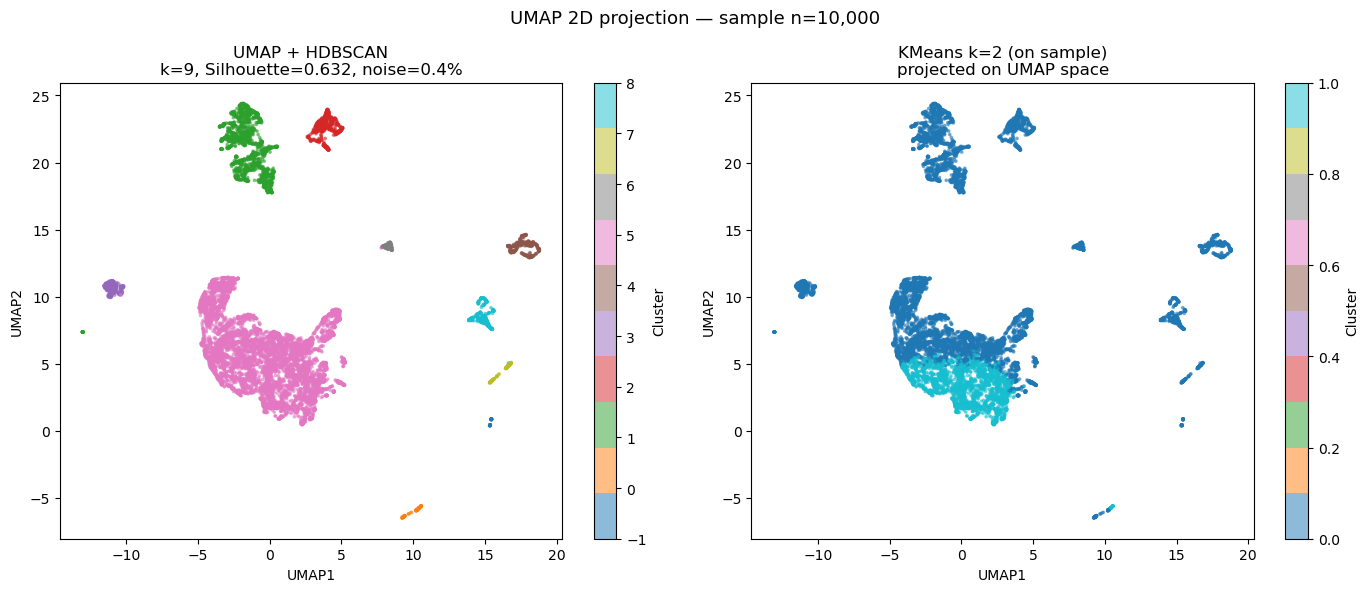


=== Profile of UMAP+HDBSCAN clusters (original values) ===
Cluster sizes:
cluster
0     120
1    1560
2     542
3     300
4     302
5    6539
6     144
7     138
8     316
Name: count, dtype: int64

Medians per cluster:
cluster                    0        1        2        3        4        5        6        7        8
perimeter              1.609    1.485    1.609    1.689    0.693    2.105    0.881    1.099    0.693
equivalent_diameter    2.764    1.954    2.257    2.257    1.954    3.192    1.954    2.257    1.954
aspect_ratio           1.000    1.732    1.000    2.618    1.000    1.791    1.732    1.000    1.000
compactness            1.299    1.586    1.609    1.770    0.288    2.061    0.511    0.693    0.288
solidity               1.000    1.000    1.000    1.000    1.000    0.846    0.750    1.000    1.000
mean_intensity       142.650  142.000  132.000  144.100  140.667  136.800  150.667  143.625  144.000
std_intensity          2.896    2.449    5.253    2.603    2.357    4.91

In [ ]:
import matplotlib.pyplot as plt

# UMAP 2D visualization
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                       metric='euclidean', random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# UMAP + HDBSCAN
scatter = axes[0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                          c=labels_umap, cmap='tab10', s=3, alpha=0.5)
axes[0].set_title(f'UMAP + HDBSCAN\nk=9, Silhouette=0.632, noise=0.4%')
axes[0].set_xlabel('UMAP1'); axes[0].set_ylabel('UMAP2')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# KMeans k=2 on same UMAP projection
km2_sample = KMeans(n_clusters=2, init='k-means++', n_init=15, random_state=42)
labels_km2_sample = km2_sample.fit_predict(X_sample)
scatter2 = axes[1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1],
                           c=labels_km2_sample, cmap='tab10', s=3, alpha=0.5)
axes[1].set_title(f'KMeans k=2 (on sample)\nprojected on UMAP space')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('UMAP 2D projection — sample n=10,000', fontsize=13)
plt.tight_layout()
plt.savefig('umap_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Profile of the 9 UMAP+HDBSCAN clusters
mask = labels_umap != -1
df_sample = df_clean.iloc[idx_sample].copy()
df_sample_clean = df_sample[mask].copy()
df_sample_clean['cluster'] = labels_umap[mask]

print("\n=== Profile of UMAP+HDBSCAN clusters (original values) ===")
print(f"Cluster sizes:")
print(df_sample_clean['cluster'].value_counts().sort_index())
print(f"\nMedians per cluster:")
print(df_sample_clean.groupby('cluster').median().round(3).T.to_string())

In [ ]:
# ¿Los clusters pequeños son outliers residuales o tipos reales?
# Comparar con las variables antes de escalar

print("=== Equivalent diameter por cluster ===")
print(df_sample_clean.groupby('cluster')['equivalent_diameter'].describe().round(3))

print("\n=== Mean intensity por cluster ===")
print(df_sample_clean.groupby('cluster')['mean_intensity'].describe().round(3))

print("\n=== Solidity por cluster ===")
print(df_sample_clean.groupby('cluster')['solidity'].describe().round(3))

=== Equivalent diameter por cluster ===
          count   mean    std    min    25%    50%    75%    max
cluster                                                         
0         120.0  2.699  0.940  1.954  1.954  2.764  3.037  6.770
1        1560.0  1.957  0.030  1.954  1.954  1.954  1.954  2.523
2         542.0  2.255  0.022  1.954  2.257  2.257  2.257  2.257
3         300.0  2.296  0.094  2.257  2.257  2.257  2.257  2.523
4         302.0  1.954  0.000  1.954  1.954  1.954  1.954  1.954
5        6539.0  3.605  1.479  1.954  2.523  3.192  4.068  9.305
6         144.0  1.998  0.120  1.954  1.954  1.954  1.954  2.523
7         138.0  2.259  0.023  2.257  2.257  2.257  2.257  2.523
8         316.0  1.955  0.017  1.954  1.954  1.954  1.954  2.257

=== Mean intensity por cluster ===
          count     mean     std     min      25%      50%      75%      max
cluster                                                                     
0         120.0  132.869  33.307  10.647  122.381  142.

In [ ]:
# Perfil completo de todos los clusters con todas las variables de clustering
df_sample_clean = df_clean.iloc[idx_sample].copy()
df_sample_clean = df_sample_clean[labels_umap != -1].copy()
df_sample_clean['cluster'] = labels_umap[labels_umap != -1]

print("=== Cluster sizes ===")
print(df_sample_clean['cluster'].value_counts().sort_index())

print("\n=== Median per cluster — all variables ===")
medians = df_sample_clean.groupby('cluster').median().round(3)
print(medians.T.to_string())

print("\n=== Std per cluster — all variables ===")
stds = df_sample_clean.groupby('cluster').std().round(3)
print(stds.T.to_string())

=== Cluster sizes ===
cluster
0     120
1    1560
2     542
3     300
4     302
5    6539
6     144
7     138
8     316
Name: count, dtype: int64

=== Median per cluster — all variables ===
cluster                    0        1        2        3        4        5        6        7        8
perimeter              1.609    1.485    1.609    1.689    0.693    2.105    0.881    1.099    0.693
equivalent_diameter    2.764    1.954    2.257    2.257    1.954    3.192    1.954    2.257    1.954
aspect_ratio           1.000    1.732    1.000    2.618    1.000    1.791    1.732    1.000    1.000
compactness            1.299    1.586    1.609    1.770    0.288    2.061    0.511    0.693    0.288
solidity               1.000    1.000    1.000    1.000    1.000    0.846    0.750    1.000    1.000
mean_intensity       142.650  142.000  132.000  144.100  140.667  136.800  150.667  143.625  144.000
std_intensity          2.896    2.449    5.253    2.603    2.357    4.918    1.247    2.861    2.160
in